## Semantic Structure in Color Representation

In [1]:
model_name = 'intern' # 'qwen', 'intern' or 'gemma'
regenerate_activations = False # If false, uses pre-stored VLM activations 
                               # to plot data instead of generating them 
                               # from scratch.

#### Import and utilities

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from ast import literal_eval # to get dict/list from csv
import pickle
import hydra
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import colorsys
from tqdm import tqdm
from PIL import Image
from PIL.ImageDraw import Draw
from omegaconf import OmegaConf
from transformers.utils import ModelOutput
from transformers import GenerationConfig

plt.rcParams['figure.constrained_layout.use'] = True 

import pyrootutils,sys
pyrootutils.setup_root('.',cwd=True,pythonpath=False)
sys.path.append('./src')

In [3]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
hydra.initialize("config")
cfg = hydra.compose("activations_gen", overrides=[dict(qwen='+experiment=bal_qwen7b',
                                                       intern='+experiment=bal_internvl8b',
                                                       gemma='+experiment=bal_gemma12b')[model_name],
                                                  ])
probelabel = 'mmp' #layer used to read hidden activations (defined in config)

/tmp/ipykernel_2606870/3837993164.py:2: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize("config")


In [4]:
colors=cfg.dataset.COLORS.copy()
shapes=cfg.dataset.SHAPES.copy()
marker_shapes = ["\U000025A0","\U000025B2","\U000025CF","\U00002B1F","\U00002605","\U00002764"]

def simmatrix(V):
  'returns a matrix of cosine similarities'
  n=V.shape[0]
  sims = torch.empty(n,n)
  for i in range(n):
    sims[i]=torch.cosine_similarity(V,V[i])
  return sims

In [ ]:
def _generate_output_hook(layer_name : str,inner_output : dict):
  '''Returns an hook that saves layer outputs to the list inner_output[layer_name],
  ignoring the outputs during generation.
  '''
  inner_output[layer_name] = []
  def prompt_output_hook(model, input, output):
      if isinstance(output, tuple):
        #print(output[0].shape)
        output = output[0] 
        tosave = output.detach().cpu()
      elif isinstance(output,torch.Tensor):
        tosave = output.detach().cpu()
      elif isinstance(output, ModelOutput):
        tosave = output['last_hidden_state'].detach().cpu()
      else:
        raise Exception(f"Hook in layer {layer_name}: output type unknown, {type(output)}")

      if tosave.shape[1]>1: 
        inner_output[layer_name].append(tosave)
  return prompt_output_hook

##### Machinery to make images

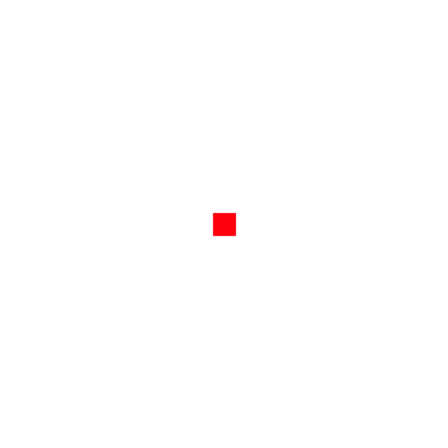

In [ ]:
colors = np.array([colorsys.hsv_to_rgb(h.item(),1.,1.) for h in np.linspace(0,1,101)[:-1]])
df2 = pd.DataFrame()
df2['r']= colors[:,0]
df2['g'] = colors[:,1]
df2['b'] = colors[:,2]
df2['h'] = np.linspace(0,1,101)[:-1]
df2['s'] = 1.
df2['v'] = 1.
df2.to_csv('./outputs/semanticity/100colors.csv')

constants = OmegaConf.to_container(cfg.dataset.constants)
stencils = np.load('./data/stencils.npy')


constants['SHAPES_NP'] = { 
    # arrays of greyscale (1-0) images (1 will be colored); all potential shapes to be included
    'triangle': stencils[9],
    'square': stencils[-1],
    'pentagon': stencils[59],
    'circle': stencils[-2],
    'star': stencils[-4],
    'heart': stencils[-6],
    'spade': stencils[51]
  }

from vlm_datasets.shapecol_unbal import color_shape

def create_image(shape,color,constants):
  canvasdim = 448
  img = Image.new('RGB', (canvasdim,canvasdim), 'white')

  shape_img = constants['SHAPES_NP'][shape]
  colored_shape = color_shape(shape_img.transpose(), color) # Returns (3, H, W)
  shape_pil = Image.fromarray(colored_shape.transpose())
  if shape_pil.size != (constants['STENCIL_SIZE'], constants['STENCIL_SIZE']):
        shape_pil = shape_pil.resize((constants['STENCIL_SIZE'], constants['STENCIL_SIZE']))
  paste_x = canvasdim//2 - constants['STENCIL_SIZE'] // 2
  paste_y = canvasdim//2 - constants['STENCIL_SIZE'] // 2
  img.paste(shape_pil, (paste_x, paste_y))
  return img
create_image('square',colors[-1],constants)

##### Generate/load activations

In [ ]:
cv_path = os.path.join('outputs','semanticity',cfg.model.model_name+'_nsq_cv.pt')


if os.path.isfile(cv_path) and not regenerate_activations:
  color_cv = torch.load(cv_path)

else:
  model = hydra.utils.instantiate(cfg.model)

  ## Generation config
  if 'Intern' in cfg.model.model_name:
      generation_kwargs = dict(generation_config=GenerationConfig( 
      max_new_tokens= 4, 
      do_sample= False, #avoid sampling outputs (greedy choice)
      return_dict_in_generate= True,  #outputs is a dictionary, following args specify its contents
      output_attentions= False, # Passed to all submodels, needed to use hooks
      output_hidden_states= False,
      output_logits= True,  # These are handy
      output_scores= False,
      eos_token_id=92542
      ) )
      # I'll move this to the model class sooner or later
      def getstring(model,output,input_len):
        return model.processor.decode(output['sequences'][0])
  else:
      generation_kwargs = { 
        "max_new_tokens": 4,
        "do_sample": False, #avoid sampling outputs (greedy choice)
        "return_dict_in_generate": True,  #outputs is a dictionary, following args specify its contents
        "output_attentions": False, # Passed to all submodels, needed to use hooks
        "output_hidden_states": False,
        "output_logits": True,  # These are handy
        "output_scores": False,
      }
      def getstring(model,output,input_len):
          return model.processor.decode(output['sequences'][0][input_len:])

  ##### Data acquisition
  inner_out = {}
  handles  = model.register_hooks(hook_generator = _generate_output_hook,
                      hook_layers = cfg.model.probe_layers,
                      hook_generator_kwargs={'inner_output': inner_out})
  probs_ids = [] # top 10 first tokens (indexes 0-~150k)
  probs = [] # their output probabilities
  logits = [] # their output logit
  outs = [] # the output string

  for i,col in tqdm(enumerate(colors[:1])):
      img = create_image('square',col,constants)
      prompt= "What color is the square? Answer in one word."
      model_input = model.get_inputs(img,prompt)
      with torch.inference_mode():
        generation_output = model.model.generate(**model_input,**generation_kwargs)
      input_len = model_input["input_ids"].shape[-1]
      str_out = getstring(model,generation_output,input_len)
      outputsm = torch.nn.functional.softmax(generation_output['logits'][0],dim=-1)
      top_probs, top_ids = (outputsm[0].topk(10)) #take top 10 scores for the first token
      logits_out = (generation_output['logits'][0][0,top_ids].cpu())
      
      probs.append(top_probs.cpu())
      probs_ids.append(top_ids.cpu())
      outs.append(str_out) #full string
      logits.append(logits_out)
      
  with open(os.path.join('outputs','semanticity',cfg.model.model_name+'_nsq_cv.pkl'),'wb') as f:
    pickle.dump(inner_out,f)
  actensor = torch.stack(inner_out['mmp'])
  actensor_center = actensor[:,[119,120,135,136],:] # keep only tokens whose corresponding patches
                                                    # intersect the square
  color_cv = F.normalize(actensor_center.mean(dim=1)-actensor_center.mean(dim=(0,1)).unsqueeze(0),
                       dim=1)
  torch.save(color_cv,cv_path)


In [8]:
colsims = simmatrix(color_cv)

### PCA Projection

In [9]:
u,s,v = torch.pca_lowrank(color_cv,q=100,center=False)

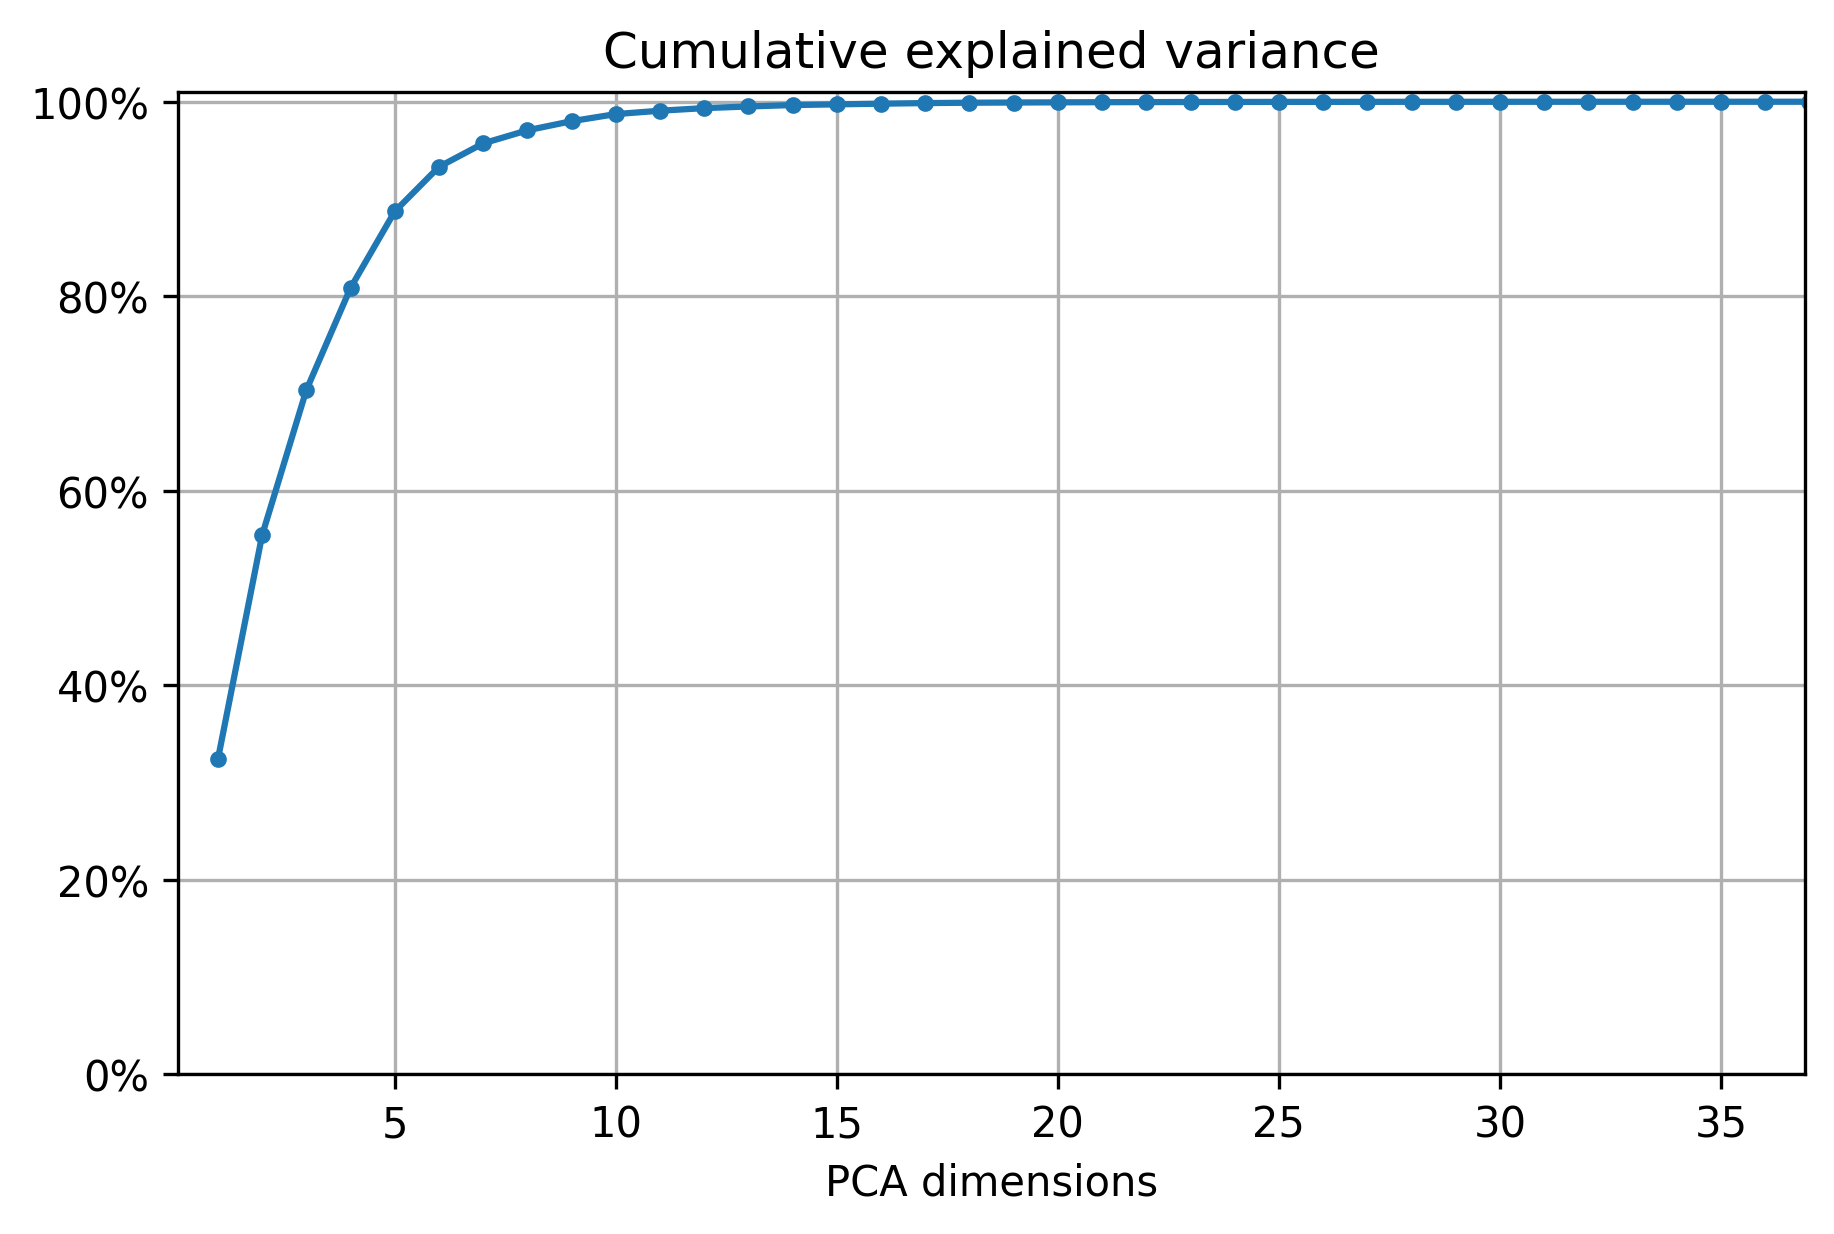

In [10]:
plt.close('all')
fig,ax = plt.subplots(figsize=(6,4),dpi=300)
ax.plot(np.arange(1,101),(s**2/(s**2).sum()).cumsum(axis=0)*100,
        '.-')

ax.set_ylim(0,101)
ax.set_xlim(0.1,36.9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Cumulative explained variance')
ax.set_xlabel('PCA dimensions')
ax.grid()

/tmp/ipykernel_2606870/2705388976.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, z, c=colors, cmap='hsv', s=30)


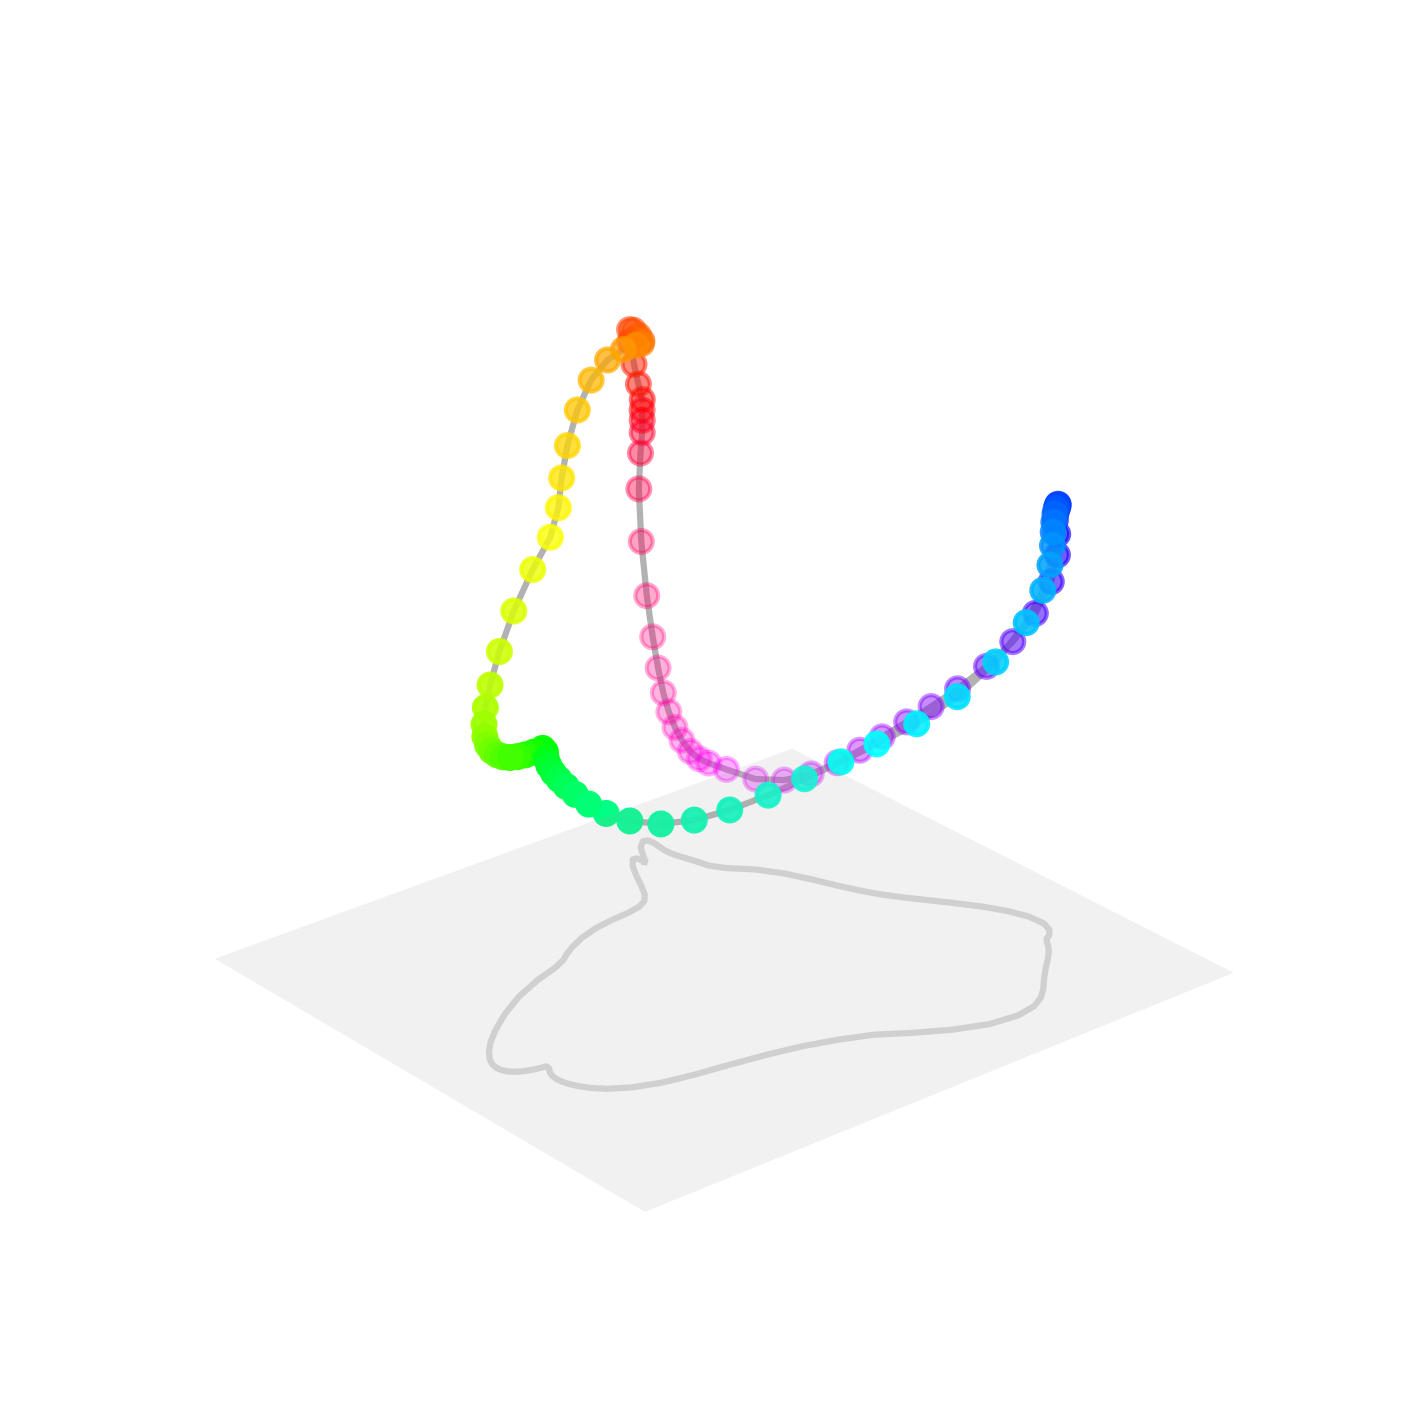

In [11]:
proj = color_cv@v[:,:3]

x = proj[:,0].numpy()
y = proj[:,1].numpy()
z = proj[:,2].numpy()

fig = plt.figure(layout='tight',dpi = 300)
ax = fig.add_subplot(111, projection="3d")

ax.plot(x, y, z, '-', c='black',alpha = 0.3)
sc = ax.scatter(x, y, z, c=colors, cmap='hsv', s=30)

z_floor = z.min() - 0.2*(z.max()-z.min())

ax.plot(x, y, np.full_like(z, z_floor),
           color="k", alpha=0.15)

X, Y = np.meshgrid(
    np.linspace(x.min()-.2, x.max()+.2, 20),
    np.linspace(y.min()-.2, y.max()+.2, 20)
)
Z = np.full_like(X, z_floor)

ax.plot_surface(X, Y, Z,
                color="lightgray",
                alpha=0.15,
                linewidth=0,
                shade=True)

ax.set_axis_off()
ax.view_init(elev=25, azim=-130)


ax.set_box_aspect([
    x.max() - x.min(),
    y.max() - y.min(),
    z.max() - z.min()
])

plt.show()
fig.savefig(f'./outputs/semanticity/plots/{model_name}_manifold.pdf',bbox_inches='tight')

### Similarity Matrix

/tmp/ipykernel_2606870/501233686.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plt.xticks(torch.tensor(plothues)+0.5,huelabels,rotation='horizontal')
/tmp/ipykernel_2606870/501233686.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plt.yticks(torch.tensor(plothues)+0.5,huelabels)


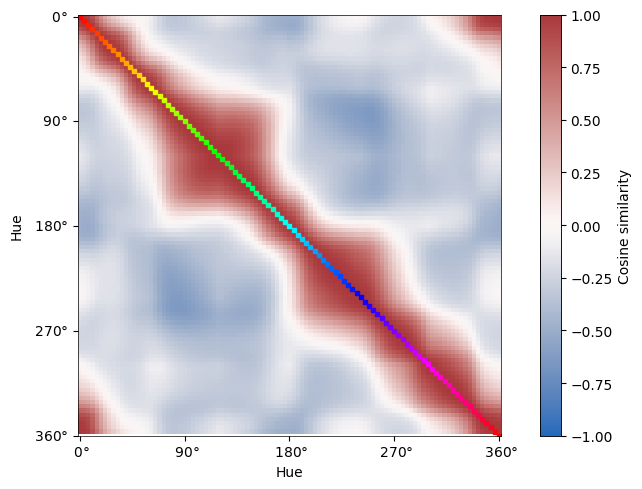

In [ ]:
ccolsims = torch.cat([colsims,colsims[:,[0]]],dim=1) #repeat first row&column as last (0°=360°)
ccolsims[-1,:-1]=colsims[0,:]
ccolsims.shape
plt.close('all')
fig = plt.figure(dpi=100,figsize=(8,5),layout='tight')
ax = sns.heatmap(ccolsims,square=True,
            cmap=sns.color_palette('vlag',as_cmap=True),
            vmin=-1.,vmax=1.,
            linewidths=0.0,
            cbar_kws=dict(label='Cosine similarity'),
            )
cax = fig.axes[1]
cax.xaxis.set_ticks_position('both')
for spine in cax.spines.values():
  spine.set_visible(True)
  spine.set_lw(0.5)
for spine in ax.spines.values():
  spine.set_visible(True)
  spine.set_lw(0.5)


for i in range(100):
  plt.plot(i+.5,i+.5,'s',c=colors[i],markersize=2.5)
plt.plot(100+.5,100+.5,'s',c=colors[0],markersize=2.5)


plothues = torch.tensor([0,90,180,270,360])/360*100
huelabels = [f' ${int(i/100.*360)}\\degree$' for i in plothues]
plt.xticks(torch.tensor(plothues)+0.5,huelabels,rotation='horizontal')
plt.yticks(torch.tensor(plothues)+0.5,huelabels)

plt.ylabel('Hue')
plt.xlabel('Hue')
plt.grid(False)
#plt.title(f'{cfg.model.model_nicename}')
fig.savefig(f'./outputs/semanticity/plots/{model_name}_colsim.pdf',bbox_inches='tight')

### Semantic similarity functions

In [13]:
simcurves = torch.zeros(100,101)
for i in range(100):
  simcurves[i,:-1]=torch.roll(colsims[i%100],150-i)
simcurves[:,-1] = simcurves[:,0] #repeat extremal values as -180°=+180°

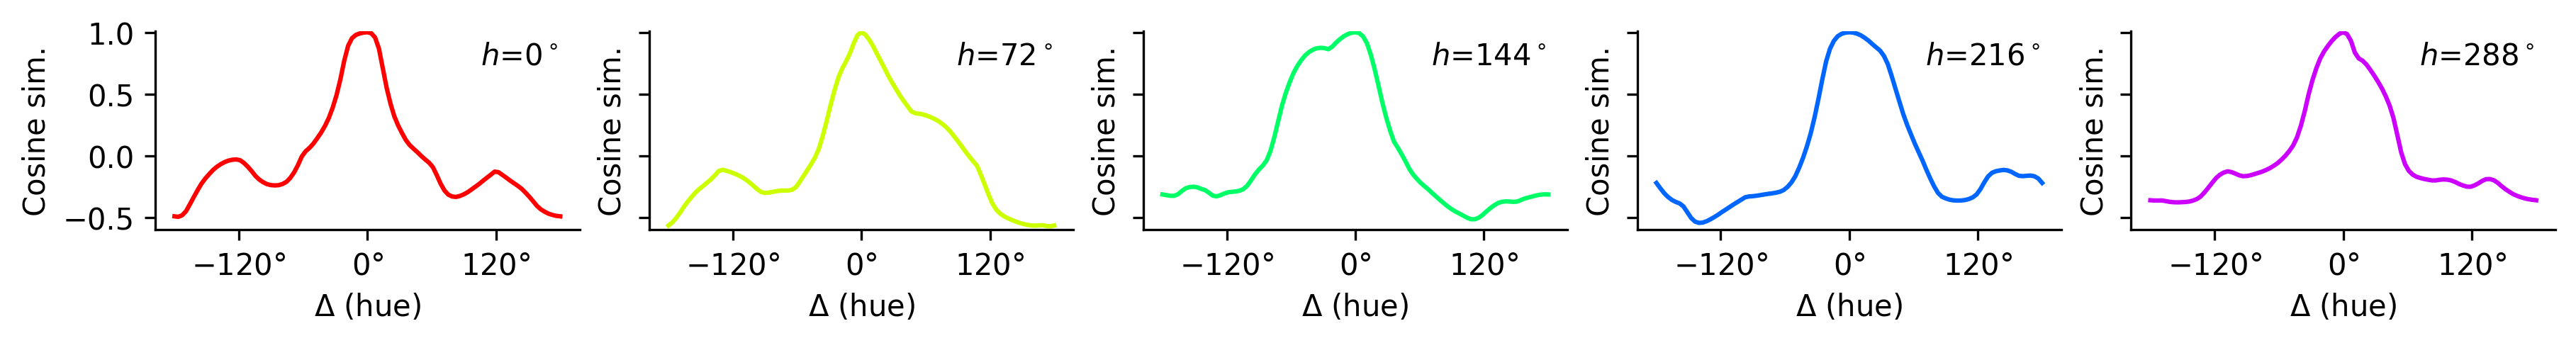

In [14]:
plt.close('all')
fig,ax = plt.subplots(ncols=5,dpi=300,layout='constrained',figsize=(12,1.5),sharey=True)
for i, r in enumerate(np.linspace(0,100,6,dtype=int)[:-1]):
  ax[i].plot(np.linspace(-180,180,101),(simcurves[r,:]),
        c=colors[r],linestyle='-',linewidth=1.5,label=f'$h={r/100*360:.0f}^\\circ$')
  ax[i].text(0.95, 0.95, f'$h$=${r/100*360:.0f}^\\circ$', transform=ax[i].transAxes, 
        fontsize=10, 
        horizontalalignment='right',verticalalignment='top')

for a in ax:
  a.set_ylabel('Cosine sim.')
  a.set_ylim(-0.6,1.01)
  a.set_xlabel('$\\Delta$ (hue)')
  a.set_xticks(np.arange(-120,121,120),[f'${i}\\degree$' for i in range(-120,121,120)])
  a.set_yticks(np.arange(-0.5,1.01,0.5))
  [s for s in a.spines.values()][1].set_visible(False)
  [s for s in a.spines.values()][3].set_visible(False)

plt.savefig(f'outputs/semanticity/plots/{model_name}_multiple.pdf',bbox_inches='tight')
plt.grid(False)

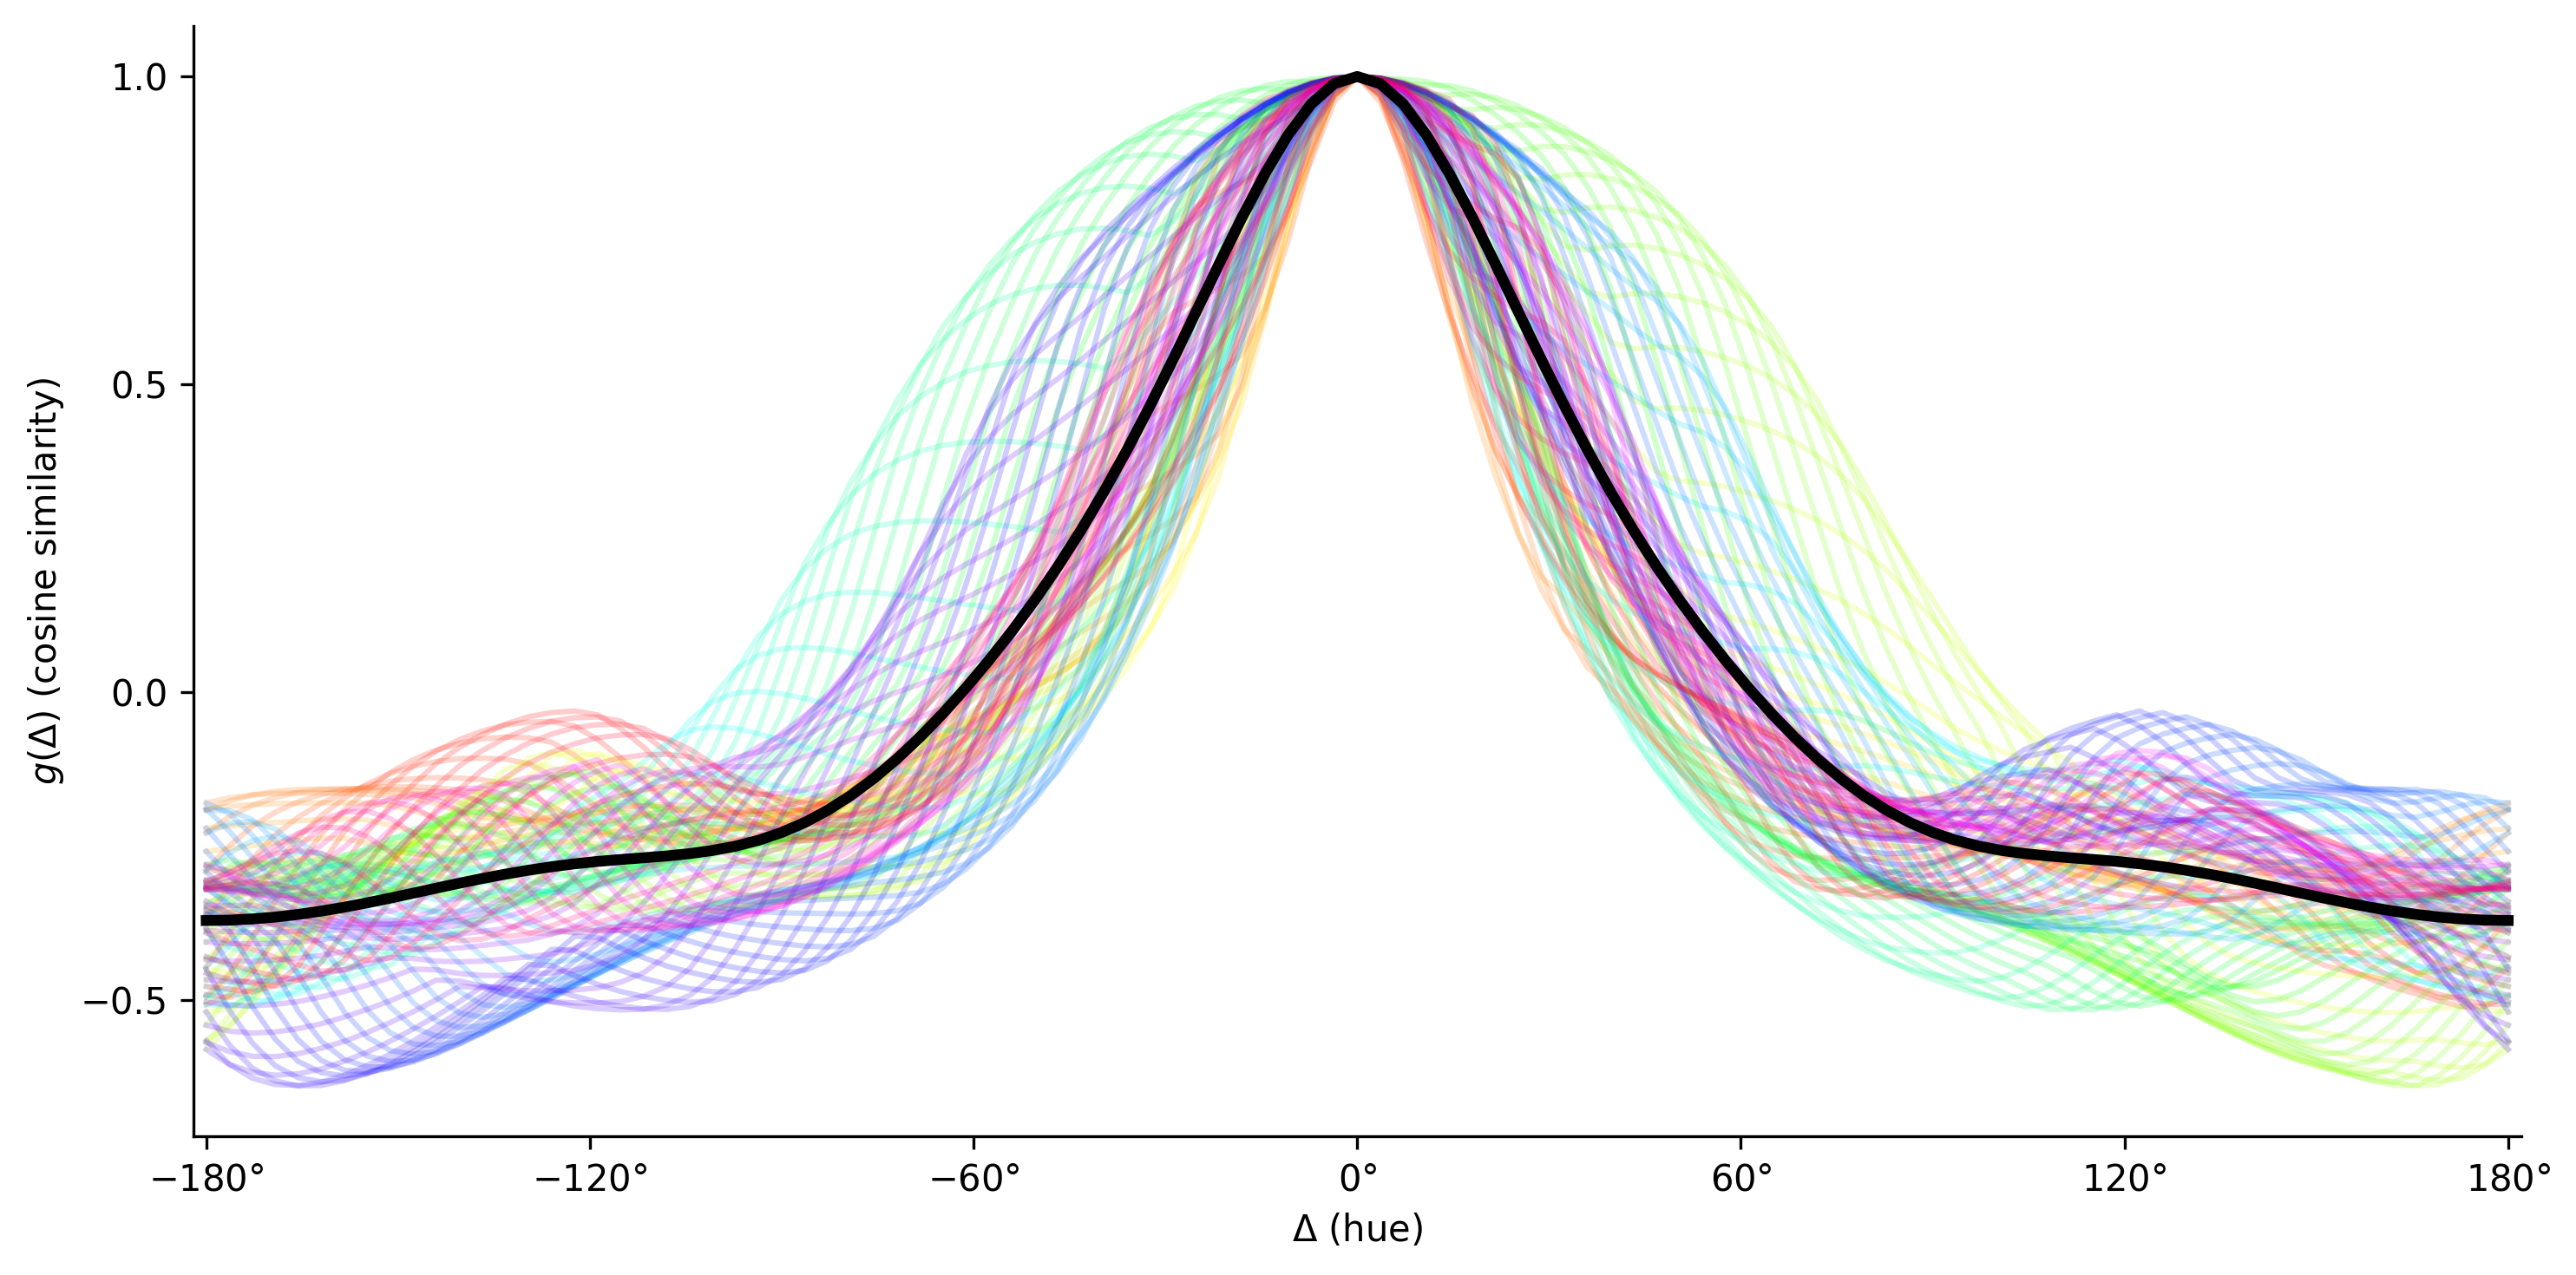

In [15]:
plt.close('all')
plt.figure(dpi=300,layout='tight',figsize=(10,5))
for i in range(simcurves.shape[0])[:]:
  plt.plot(np.linspace(-180,180,101),(simcurves[i,:]),alpha=.2,c=colors[i%100])
plt.plot(np.linspace(-180,180,101),(simcurves.mean(dim=0)),
        c='black',linestyle='-',linewidth=3)
plt.xlim(-182,182)
#plt.ylim(-0.6,1.001)
plt.ylabel('$g(\\Delta)$ (cosine similarity)')
plt.xlabel('$\\Delta$ (hue)')
plt.xticks(np.arange(-180,181,60),[f'${i}\\degree$' for i in range(-180,181,60)])
plt.yticks(np.arange(-0.5,1.01,0.5))
splines = [s for s in plt.gca().spines.values()]
splines[1].set_visible(False)
splines[3].set_visible(False)

plt.grid(False)
plt.savefig(f'outputs/semanticity/plots/{model_name}_mexhat.pdf')